# Market Volatility Analysis: Impact of Recessions on Automobile Sales

**Author:** Zaara Shaikh<br>
**Project Type:** Data Visualization & Business Intelligence<br>
**Tools:** Python (Matplotlib, Seaborn, Folium, Pandas)

## Business Scenario
XYZAutomotives, a leading vehicle manufacturer, requires a historical analysis of how economic downturns (recessions) impact automobile sales. As a Data Analyst, I have been tasked with analyzing sales data from 1980 to 2023 to discern patterns in consumer buying behavior during crisis periods.

## Objectives
* **Trend Analysis:** Visualize sales volume fluctuations across varying economic conditions.
* **Product Performance:** Identify which vehicle categories (Sports, SUV, Family) are most resilient during recessions.
* **Economic Correlation:** Correlate external economic drivers (GDP, Unemployment) with sales performance to guide future inventory planning.

### Installing Required Libraries

In [1]:
%pip install pandas
%pip install numpy
%pip install seaborn
%pip install folium

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


### Importing Required Libraries

In [2]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import folium

---


### Data Description
The dataset used is *historical_automobile_sales* data representing automobile sales and related variables during recession and non-recession period. 
The dataset includes the following variables:
<br>1. Date: The date of the observation.
<br>2. Recession: A binary variable indicating recession perion; 1 means it was recession, 0 means it was normal.
<br>3. Automobile_Sales: The number of vehicles sold during the period.
<br>4. GDP: The per capita GDP value in USD.
<br>5. Unemployment_Rate: The monthly unemployment rate.
<br>6. Consumer_Confidence: A synthetic index representing consumer confidence, which can impact consumer spending and automobile purchases.
<br>7. Seasonality_Weight: The weight representing the seasonality effect on automobile sales during the period.
<br>8. Price: The average vehicle price during the period.
<br>9. Advertising_Expenditure: The advertising expenditure of the company.
<br>10.Vehicle_Type: The type of vehicles sold; Supperminicar, Smallfamiliycar,                 Mediumfamilycar, Executivecar, Sports.
<br>11.Competition: The measure of competition in the market, such as the number of competitors or market share of major manufacturers.
<br>12.Month: Month of the observation extracted from Date..
<br>13.Year: Year of the observation extracted from Date.<br>

### Recession period insights
recession period 1 - year 1980 <br>
recession period 2 - year 1981 to 1982<br>
recession period 3 - year 1991<br>
recession period 4 - year 2000 to 2001<br>
recession period 5 - year end 2007 to mid 2009<br>
recession period 6 - year 2020 -Feb to April (Covid-19 Impact)<br>

---


### Importing Data


In [3]:
import pandas as pd

# Standard URL for the CSV file
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/historical_automobile_sales.csv"

# Load the data directly using Pandas
df = pd.read_csv(URL)

print("Data loaded successfully!")
df.head()

Data loaded successfully!


,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1/31/1980,1980,Jan,1,108.24,0.50,27483.571,1558,7,60.223,0.010000,5.4,456.0,Supperminicar,Georgia
1,2/29/1980,1980,Feb,1,98.75,0.75,24308.678,3048,4,45.986,-0.309594,4.8,555.9,Supperminicar,New York
2,3/31/1980,1980,Mar,1,107.48,0.20,28238.443,3137,3,35.141,-0.308614,3.4,620.0,Mediumfamilycar,New York
3,4/30/1980,1980,Apr,1,115.01,1.00,32615.149,1653,7,45.673,0.230596,4.2,702.8,Supperminicar,Illinois
4,5/31/1980,1980,May,1,98.72,0.20,23829.233,1319,4,52.997,0.138197,5.3,770.4,Smallfamiliycar,California


In [4]:
df.describe()

,Year,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales
count,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000,528.000000
mean,2001.500000,0.214015,101.140170,0.575795,24964.991956,3067.456439,6.064394,40.073903,-0.242001,2.453977,2352.718068
std,12.710467,0.410526,10.601154,0.454477,4888.073433,1139.564637,1.968350,16.249714,0.861268,1.119019,1645.321284
min,1980.000000,0.000000,73.900000,0.000000,8793.663000,1009.000000,3.000000,12.508000,-4.227601,1.000000,102.000000
25%,1990.750000,0.000000,94.035000,0.250000,21453.300500,2083.500000,4.000000,27.237500,-0.574049,1.600000,793.950000
50%,2001.500000,0.000000,100.740000,0.500000,25038.691500,3072.000000,6.000000,39.214500,-0.013162,2.300000,2182.600000
75%,2012.250000,0.000000,108.240000,0.750000,28131.684750,4067.250000,8.000000,53.506500,0.388932,2.900000,3614.800000
max,2023.000000,1.000000,131.670000,1.500000,44263.657000,4983.000000,9.000000,70.374000,0.815074,6.000000,21147.000000


In [5]:
df.columns

Index(['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence',
       'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition',
       'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales',
       'Vehicle_Type', 'City'],
      dtype='object')

---


## Creating Visualizations for Data Analysis


### TASK 1.1: Trend Analysis: Automobile Sales Fluctuations over Time

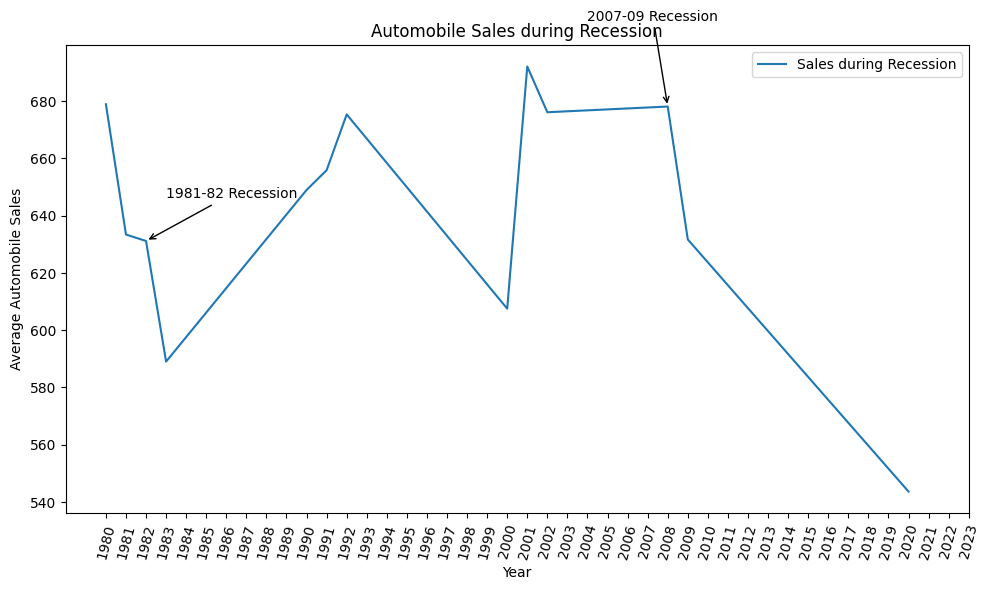

In [6]:
# Trend Analysis: Automobile Sales Fluctuations over Time
#creating recession data frame
recession_data = df[df['Recession'] ==1]
df_recession = recession_data.groupby('Year')['Automobile_Sales'].mean()

plt.figure(figsize=(10,6))
df_recession.plot(kind='line')
plt.xticks(list(range(1980, 2024)), rotation=75)
plt.xlabel('Year')
plt.ylabel('Average Automobile Sales')
plt.title('Automobile Sales during Recession')

plt.annotate('1981-82 Recession', xy=(1982, df_recession[1982]),
             xytext=(1983, df_recession[1982]+ 15),
             arrowprops=dict(arrowstyle='->', color='black'))
plt.annotate('2007-09 Recession', xy=(2008, df_recession[2008]),
             xytext=(2004, df_recession[2008]+ 30),
             arrowprops=dict(arrowstyle='->',color='black'))
plt.legend(['Sales during Recession'])

plt.tight_layout()
plt.show()

---



####  TASK 1.2: Category Analysis: Vehicle Type Trends during Recessions


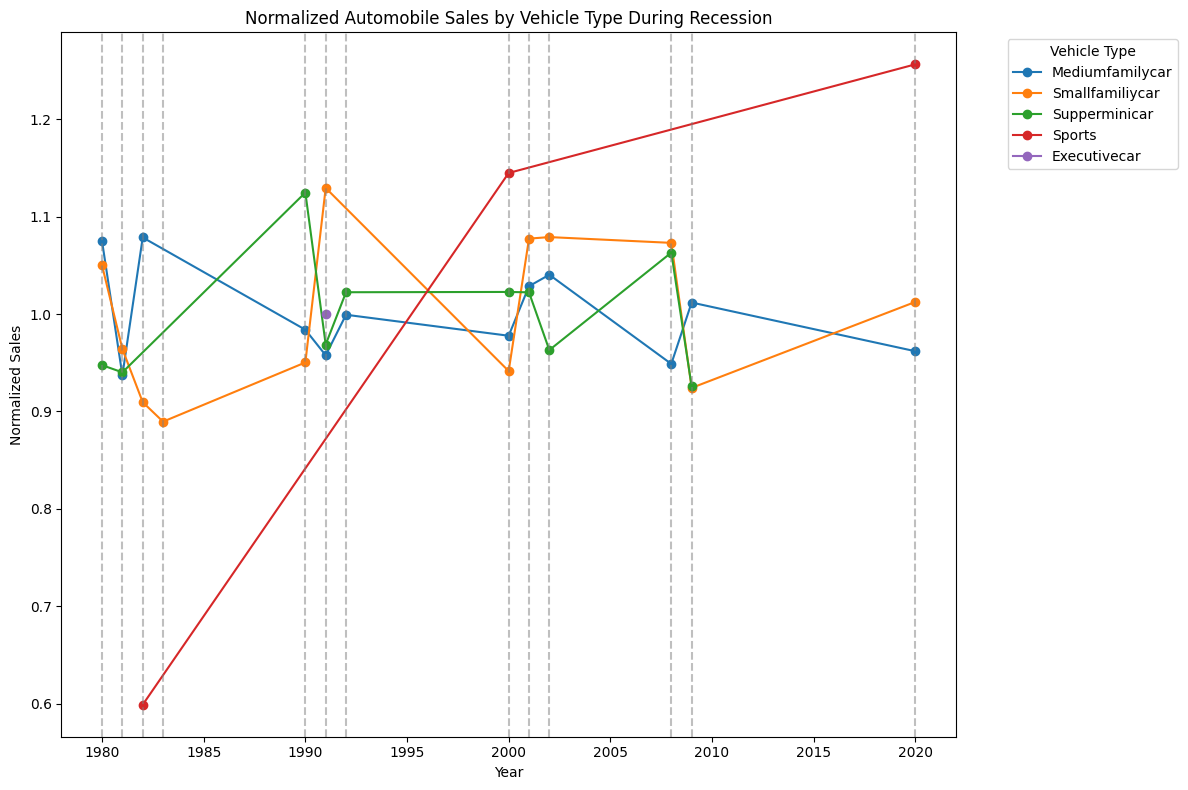

In [8]:
# Calculate the average automobile sales by year and vehicle type during the recession
df_Mline = recession_data.groupby(['Year', 'Vehicle_Type'], as_index=False)['Automobile_Sales'].mean()

# Calculate the normalized sales by dividing by the average sales for each vehicle type
df_Mline['Normalized_Sales'] = df_Mline.groupby('Vehicle_Type')['Automobile_Sales'].transform(lambda x: x / x.mean())

# Set the 'Year' as the index
df_Mline.set_index('Year', inplace=True)

# Create the plot for each vehicle type
plt.figure(figsize=(12, 8))
for vehicle_type in df_Mline['Vehicle_Type'].unique():
    data = df_Mline[df_Mline['Vehicle_Type'] == vehicle_type]
    plt.plot(data.index, data['Normalized_Sales'], label=vehicle_type, marker='o')

# Highlight recession years
recession_years = recession_data['Year'].unique()
for year in recession_years:
    plt.axvline(x=year, color='gray', linestyle='--', alpha=0.5)

# Add labels, legend, and title
plt.legend(title="Vehicle Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylabel("Normalized Sales")
plt.xlabel("Year")
plt.title("Normalized Automobile Sales by Vehicle Type During Recession")

plt.tight_layout()
plt.show()

----


### TASK 1.3: Comparative Analysis: Recession vs. Non-Recession Sales

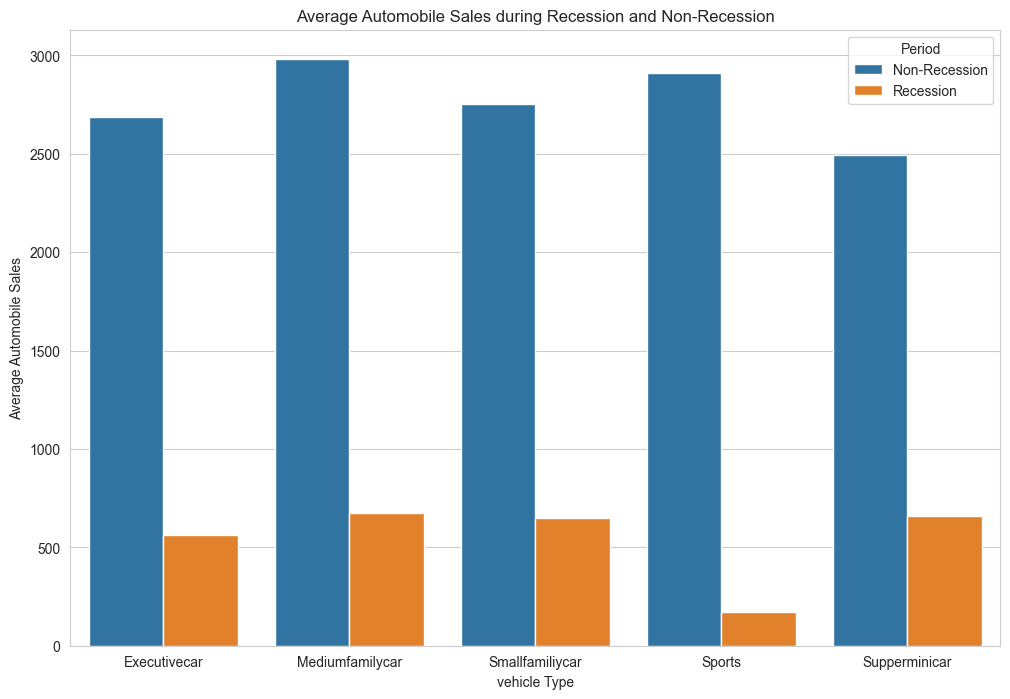

In [9]:
# Recession vs. Non-Recession Comparison
# We use a Seaborn Barplot to compare average sales across vehicle types.

df['Period'] = df['Recession'].map({0: 'Non-Recession', 1:'Recession'})
new_df = df.groupby(['Vehicle_Type','Period'], as_index=False)['Automobile_Sales'].mean()

# Create the bar chart using seaborn
plt.figure(figsize=(12,8))
sns.set_style("whitegrid")
sns.barplot(data=new_df, x='Vehicle_Type', y='Automobile_Sales', hue='Period')

plt.xlabel('vehicle Type')
plt.ylabel('Average Automobile Sales')

plt.title('Average Automobile Sales during Recession and Non-Recession')
plt.xticks(rotation=0)
plt.show()

---


### TASK 1.4: Economic Indicator: GDP Variations

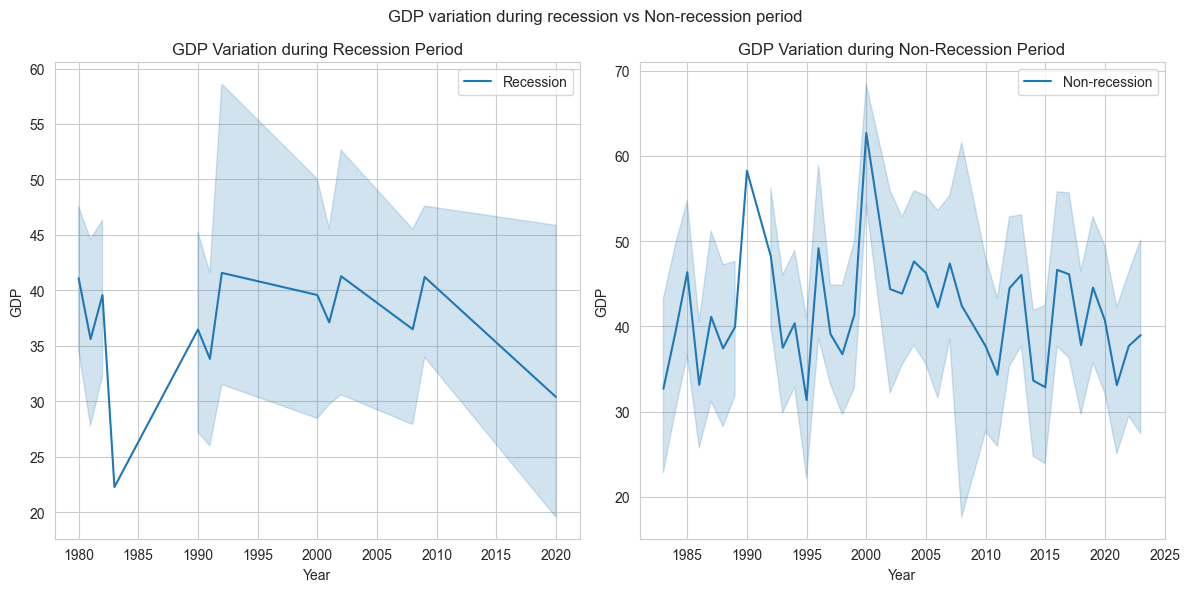

In [10]:
#Economic Indicator: GDP Variations

#Create dataframes for recession and non-recession period
rec_data = df[df['Recession'] == 1]
non_rec_data = df[df['Recession'] == 0]

#Figure
fig=plt.figure(figsize=(12, 6))

#Create different axes for subploting
ax0 = fig.add_subplot(1, 2, 1) # add subplot 1 (1 row, 2 columns, first plot)
ax1 = fig.add_subplot(1,2,2) # add subplot 2 (1 row, 2 columns, second plot). 

#plt.subplot(1, 2, 1)
sns.lineplot(x='Year', y='GDP', data=rec_data, label='Recession', ax=ax0)
ax0.set_xlabel('Year')
ax0.set_ylabel('GDP')
ax0.set_title('GDP Variation during Recession Period')

#plt.subplot(1, 2, 2)
sns.lineplot(x='Year', y='GDP', data=non_rec_data, label='Non-recession',ax=ax1)
ax1.set_xlabel('Year')
ax1.set_ylabel('GDP')
ax1.set_title('GDP Variation during Non-Recession Period')
               
plt.suptitle("GDP variation during recession vs Non-recession period")     
plt.tight_layout()
plt.show()


---


### TASK 1.5: Seasonality Impact on Sales

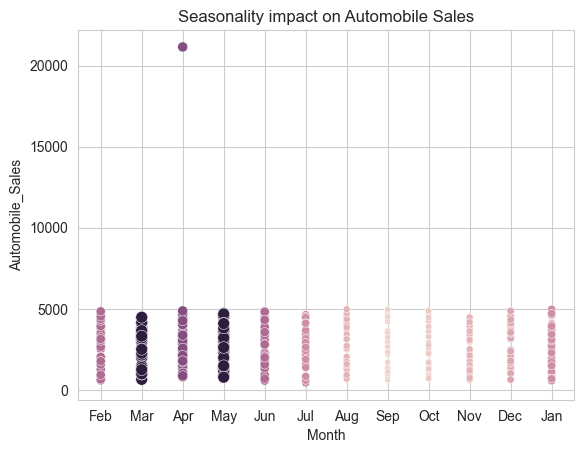

In [11]:
# Seasonality Analysis (Bubble Plot)
# A bubble plot is utilized here to display three dimensions of data simultaneously:
# X-axis: Month, Y-axis: Sales, and Bubble Size: Seasonality Weight.
# This helps identify if sales volume is driven by specific seasonal factors.

non_rec_data = df[df['Recession'] == 0]
size=non_rec_data['Seasonality_Weight'] #for bubble effect
sns.scatterplot(data=non_rec_data, x='Month', y='Automobile_Sales', size=size, hue='Seasonality_Weight', legend=False )

plt.xlabel('Month')
plt.ylabel('Automobile_Sales')

plt.title('Seasonality impact on Automobile Sales')
plt.show()

---


 ### TASK 1.6: Correlation Analysis: Price vs. Sales Volume

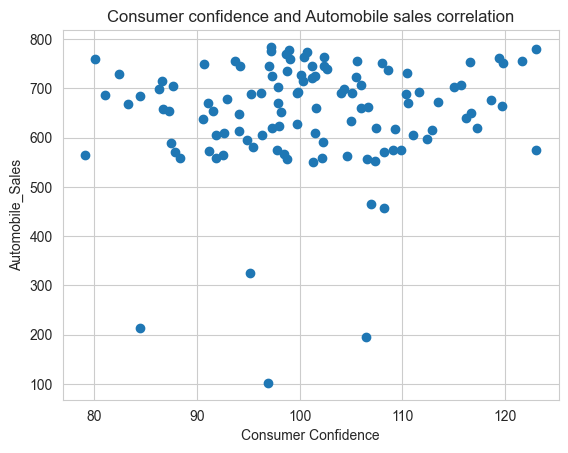

In [12]:
#Create dataframes for recession and non-recession period
rec_data = df[df['Recession'] == 1]
plt.scatter(rec_data['Consumer_Confidence'], rec_data['Automobile_Sales'])

plt.xlabel('Consumer Confidence')
plt.ylabel('Automobile_Sales')

plt.title('Consumer confidence and Automobile sales correlation')
plt.show()

 ### How does the average vehicle price relate to the sales volume during recessions?

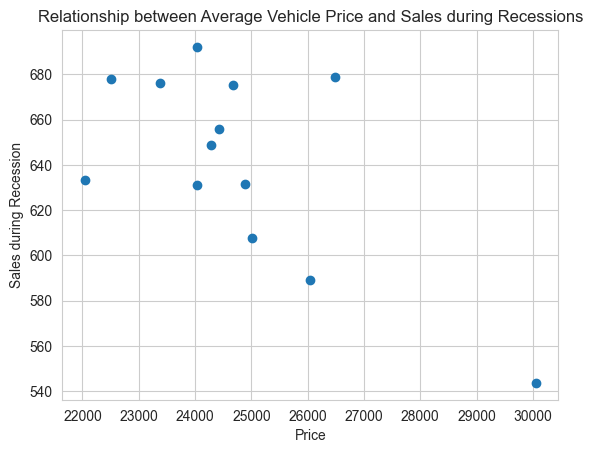

In [13]:
rec_data = df[df['Recession'] == 1]
rec_avg = rec_data.groupby('Year', as_index=False)[['Price','Automobile_Sales']].mean() #average price
plt.scatter(rec_avg['Price'], rec_avg['Automobile_Sales'])

plt.xlabel('Price')
plt.ylabel('Sales during Recession')

plt.title('Relationship between Average Vehicle Price and Sales during Recessions')
plt.show()

----


 ### TASK 1.7: Marketing Insights: Advertising Expenditure Distribution- General

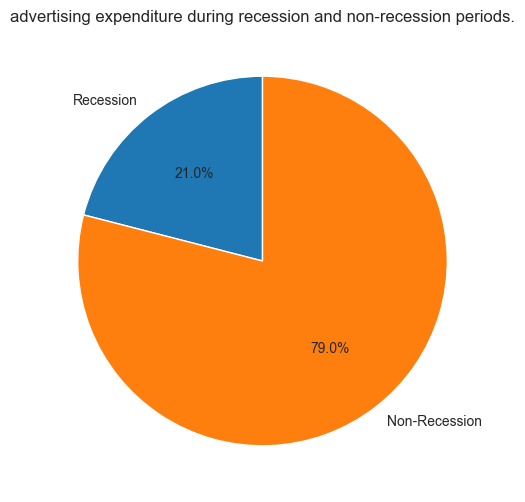

In [14]:
# Marketing Insights: Advertising Expenditure Distribution- General for all vehicle types

# Filter the data 
Rdata = df[df['Recession'] == 1]
NRdata = df[df['Recession'] == 0]

# Calculate the total advertising expenditure for both periods
RAtotal = Rdata['Advertising_Expenditure'].sum()
NRAtotal = NRdata['Advertising_Expenditure'].sum()

# Create a pie chart for the advertising expenditure 
plt.figure(figsize=(8, 6))
labels = ['Recession', 'Non-Recession']
sizes = [RAtotal, NRAtotal]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)

plt.title('advertising expenditure during recession and non-recession periods.')
plt.show()

---


### TASK 1.8: Marketing Insights: Advertising Expenditure Distribution for each vehicle type

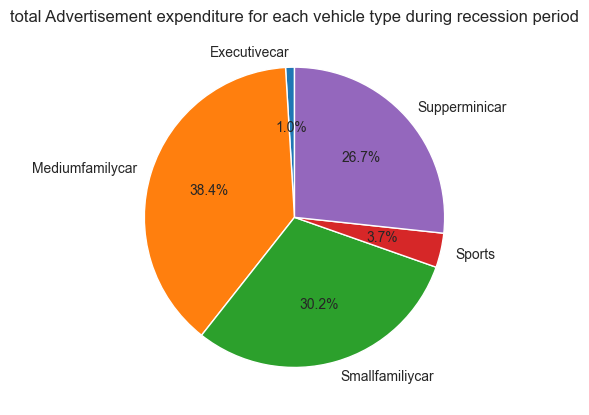

In [15]:
# Marketing Insights: Advertising Expenditure Distribution for each vehicle type

# Filter the data 
Rdata = df[df['Recession'] == 1]

# Calculate the sales volume by vehicle type during recessions
VTexpenditure = Rdata.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()

# Create a pie chart for the share of each vehicle type in total expenditure during recessions
plt.figure(figsize=(5,5))
labels = VTexpenditure.index
sizes = VTexpenditure.values
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)

plt.title('total Advertisement expenditure for each vehicle type during recession period')
plt.tight_layout()
plt.show()

----


 ### TASK 1.9: Economic Impact: Unemployment Effect on Vehicle Classes

C:\Users\Zaara\AppData\Local\Temp\ipykernel_19652\3073691851.py:7: UserWarning: 
The markers list has fewer values (1) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(data=df_rec, x='unemployment_rate', y='Automobile_Sales',


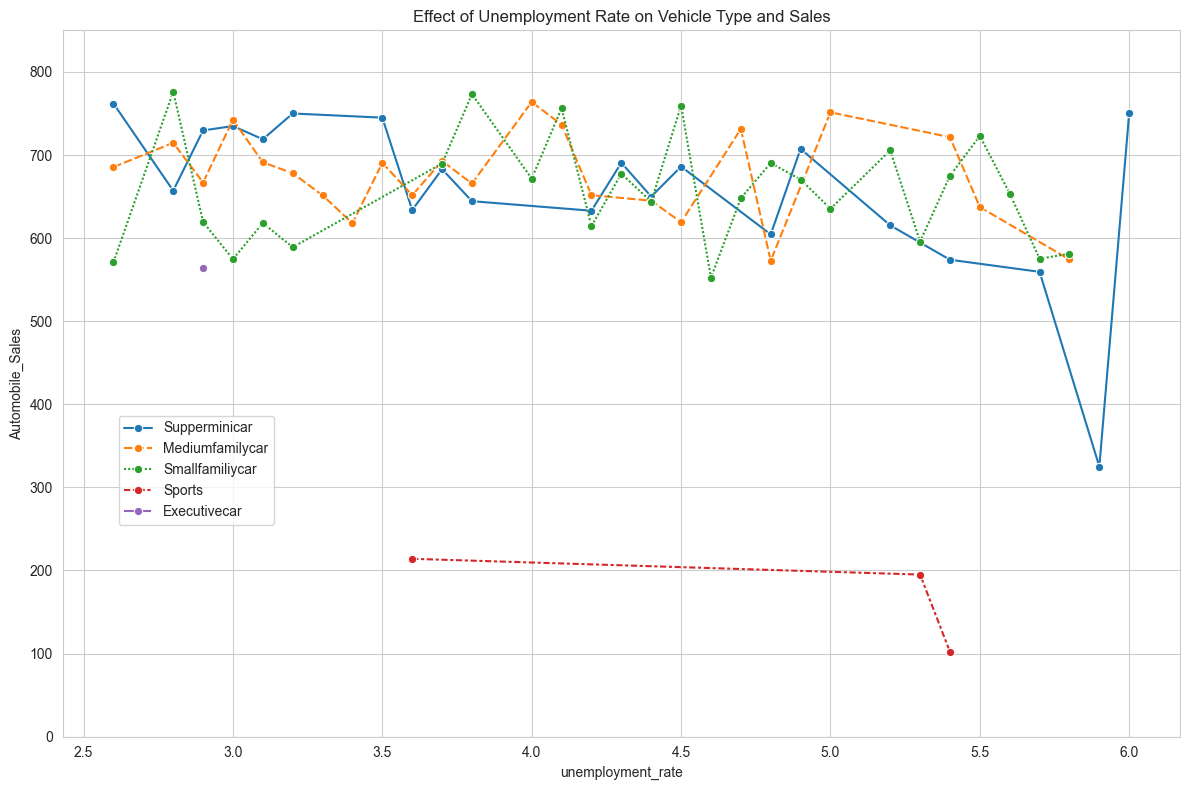

In [16]:
# Unemployment Impact Analysis
# This multi-line chart correlates the Unemployment Rate (X-axis) with Sales (Y-axis).
# Separating by 'Vehicle_Type' reveals which market segments are most sensitive to job market fluctuations.

df_rec = df[df['Recession']==1]
plt.figure(figsize=(12,8))
sns.lineplot(data=df_rec, x='unemployment_rate', y='Automobile_Sales',
             hue='Vehicle_Type', style='Vehicle_Type', markers='o', err_style=None)
plt.ylim(0,850)
plt.legend(loc=(0.05,.3))

plt.title('Effect of Unemployment Rate on Vehicle Type and Sales')
plt.tight_layout()
plt.show()

## Executive Insights & Recommendations
This visual analysis highlights distinct consumer behavioral shifts during economic recessions:

1.  **Resilience of "Need" vs. "Want":** Family and Medium-sized cars sustain moderate sales volumes during recessions, whereas luxury and sports vehicle sales plummet, indicating a shift toward utility.
2.  **Marketing Efficiency:** Advertising expenditure during non-recession periods yields significantly higher returns. During recessions, ad spend should be targeted conservatively toward economy models.
3.  **Economic Sensitivity:** There is a clear negative correlation between unemployment rates and automobile sales. However, specific vehicle types showed unexpected spikes during the early phases of recovery.

**Strategic Recommendation:** In future economic downturns, XYZAutomotives should pivot inventory and marketing focus toward **Medium Family Cars**, as they demonstrate the highest market resilience.